In [2]:
# ============================================================
# POPULATION PK/PD MODELING & SIMULATION
# Python Portfolio Project
#
# Designed for Kaggle
#
# Project:
# Population PK/PD Modeling and Exposure–Response Simulation
#
# IMPORTANT:
# This is a synthetic educational/portfolio project.
# It does NOT represent clinical data or real drug development.
# ============================================================

# ============================================================
# 1. INSTALL / IMPORT LIBRARIES
# ============================================================

import sys
import subprocess
import importlib.util

required_packages = [
    "numpy",
    "pandas",
    "scipy",
    "matplotlib",
    "seaborn",
    "scikit-learn"
]

for package in required_packages:
    if importlib.util.find_spec(package) is None:
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", package, "-q"
        ])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from scipy.stats import lognorm
from sklearn.metrics import mean_squared_error, r2_score

import os
import json
import warnings

warnings.filterwarnings("ignore")

np.random.seed(42)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [4]:
pwd

'/Users/pawanthapaliya/Downloads'

In [5]:
# ============================================================
# 2. PROJECT CONFIGURATION
# ============================================================

PROJECT_NAME = "Population PK/PD Modeling and Exposure-Response Simulation"

OUTPUT_DIR = "/Users/pawanthapaliya/Downloads/pkpd_project"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "figures"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "data"), exist_ok=True)

print("Project directory:", OUTPUT_DIR)

Project directory: /Users/pawanthapaliya/Downloads/pkpd_project


In [6]:
# ============================================================
# 3. SCIENTIFIC OBJECTIVE
# ============================================================

objective = """
Objective
---------

Develop and evaluate a synthetic population pharmacokinetic/
pharmacodynamic modeling workflow.

The analysis includes:

1. One-compartment pharmacokinetic modeling
2. Inter-individual variability
3. Residual unexplained variability
4. Population parameter simulation
5. Parameter estimation
6. PK model validation
7. Exposure-response analysis
8. Emax pharmacodynamic modeling
9. Monte Carlo simulation
10. Visualization of model predictions

All data are simulated and are intended only for educational
and portfolio purposes.
"""

print(objective)

with open(os.path.join(OUTPUT_DIR, "PROJECT_DESCRIPTION.txt"), "w") as f:
    f.write(objective)


Objective
---------

Develop and evaluate a synthetic population pharmacokinetic/
pharmacodynamic modeling workflow.

The analysis includes:

1. One-compartment pharmacokinetic modeling
2. Inter-individual variability
3. Residual unexplained variability
4. Population parameter simulation
5. Parameter estimation
6. PK model validation
7. Exposure-response analysis
8. Emax pharmacodynamic modeling
9. Monte Carlo simulation
10. Visualization of model predictions

All data are simulated and are intended only for educational
and portfolio purposes.



In [7]:
# ============================================================
# 4. PHARMACOKINETIC MODEL
# ============================================================
#
# One-compartment IV bolus model
#
# dA/dt = -k * A
#
# where:
#
# A = amount of drug in the body
# k = elimination rate constant
#
# Concentration:
#
# C(t) = A(t) / V
#
# and
#
# k = CL / V
#
# ============================================================

def pk_concentration_iv_bolus(time, dose, CL, V):
    """
    One-compartment IV bolus PK model.

    Parameters
    ----------
    time : array
        Time after dose
    dose : float
        Dose
    CL : float
        Clearance
    V : float
        Volume of distribution

    Returns
    -------
    concentration : array
    """

    k = CL / V

    concentration = (dose / V) * np.exp(-k * time)

    return concentration


# Example parameters

DOSE = 100.0       # mg
CL = 5.0           # L/hour
V = 50.0           # L

time = np.linspace(0, 24, 100)

concentration = pk_concentration_iv_bolus(
    time,
    DOSE,
    CL,
    V
)

print("Example PK parameters")
print("----------------------")
print(f"Dose       = {DOSE:.2f} mg")
print(f"Clearance  = {CL:.2f} L/h")
print(f"Volume     = {V:.2f} L")
print(f"Half-life  = {np.log(2) * V / CL:.2f} h")

Example PK parameters
----------------------
Dose       = 100.00 mg
Clearance  = 5.00 L/h
Volume     = 50.00 L
Half-life  = 6.93 h


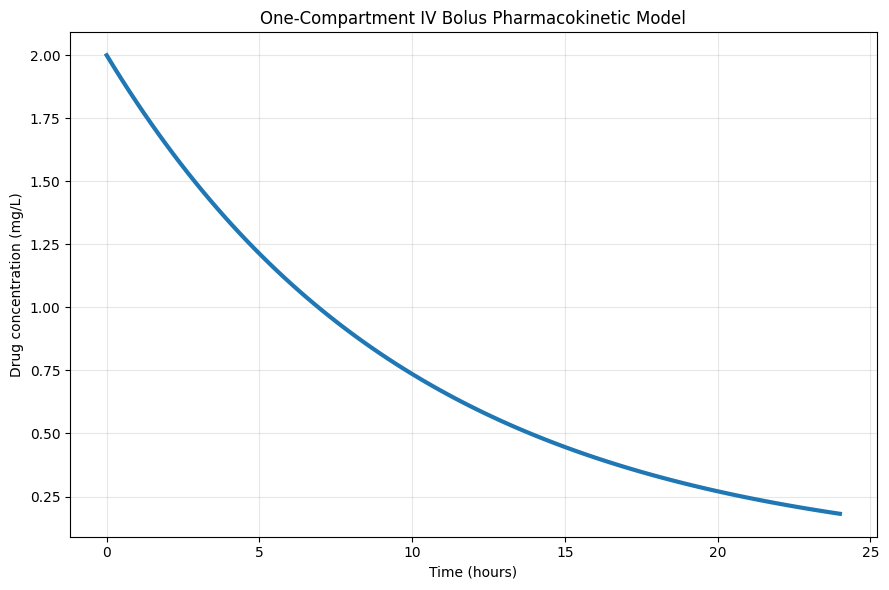

In [8]:
# ============================================================
# 5. VISUALIZE BASIC PK MODEL
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    time,
    concentration,
    linewidth=3
)

plt.xlabel("Time (hours)")
plt.ylabel("Drug concentration (mg/L)")
plt.title("One-Compartment IV Bolus Pharmacokinetic Model")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "figures",
        "01_one_compartment_pk.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
# ============================================================
# 6. SIMULATE A VIRTUAL PATIENT POPULATION
# ============================================================
#
# Population parameters:
#
# Typical clearance = 5 L/h
# Typical volume    = 50 L
#
# Inter-individual variability is represented using
# log-normal distributions.
#
# CL_i = CL_pop * exp(eta_CL)
#
# V_i  = V_pop  * exp(eta_V)
#
# ============================================================

N_PATIENTS = 100

CL_POP = 5.0
V_POP = 50.0

OMEGA_CL = 0.25
OMEGA_V = 0.20

patients = np.arange(1, N_PATIENTS + 1)

eta_cl = np.random.normal(
    0,
    OMEGA_CL,
    N_PATIENTS
)

eta_v = np.random.normal(
    0,
    OMEGA_V,
    N_PATIENTS
)

CL_individual = CL_POP * np.exp(eta_cl)

V_individual = V_POP * np.exp(eta_v)

population = pd.DataFrame({
    "ID": patients,
    "CL": CL_individual,
    "V": V_individual
})

population["half_life"] = (
    np.log(2) *
    population["V"] /
    population["CL"]
)

population.head()

,ID,CL,V,half_life
0,1,5.661090,37.673196,4.612728
1,2,4.830123,45.965630,6.596302
2,3,5.878843,46.687670,5.504727
3,4,7.316963,42.587788,4.034407
4,5,4.715710,48.412879,7.116054


In [10]:
# ============================================================
# 7. SIMULATE PK OBSERVATIONS
# ============================================================

sampling_times = np.array([
    0.25,
    0.5,
    1,
    2,
    4,
    8,
    12,
    24
])

records = []

SIGMA = 0.10

for _, patient in population.iterrows():

    true_concentration = pk_concentration_iv_bolus(
        sampling_times,
        DOSE,
        patient["CL"],
        patient["V"]
    )

    # proportional residual error

    error = np.random.normal(
        0,
        SIGMA,
        len(sampling_times)
    )

    observed_concentration = (
        true_concentration *
        np.exp(error)
    )

    for t, pred, obs in zip(
        sampling_times,
        true_concentration,
        observed_concentration
    ):

        records.append({
            "ID": int(patient["ID"]),
            "TIME": t,
            "DOSE": DOSE,
            "CL_TRUE": patient["CL"],
            "V_TRUE": patient["V"],
            "CONC_TRUE": pred,
            "CONC_OBS": obs
        })

pk_data = pd.DataFrame(records)

print("Number of observations:", len(pk_data))

pk_data.head()

Number of observations: 800


,ID,TIME,DOSE,CL_TRUE,V_TRUE,CONC_TRUE,CONC_OBS
0,1,0.25,100.0,5.66109,37.673196,2.556539,2.649664
1,1,0.50,100.0,5.66109,37.673196,2.462278,2.604304
2,1,1.00,100.0,5.66109,37.673196,2.284056,2.545324
3,1,2.00,100.0,5.66109,37.673196,1.965378,2.183796
4,1,4.00,100.0,5.66109,37.673196,1.455207,1.267924


In [11]:
# ============================================================
# 8. SAVE SYNTHETIC PK DATA
# ============================================================

pk_data.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "data",
        "synthetic_population_pk.csv"
    ),
    index=False
)

population.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "data",
        "virtual_population_parameters.csv"
    ),
    index=False
)

print("Synthetic datasets saved.")

Synthetic datasets saved.


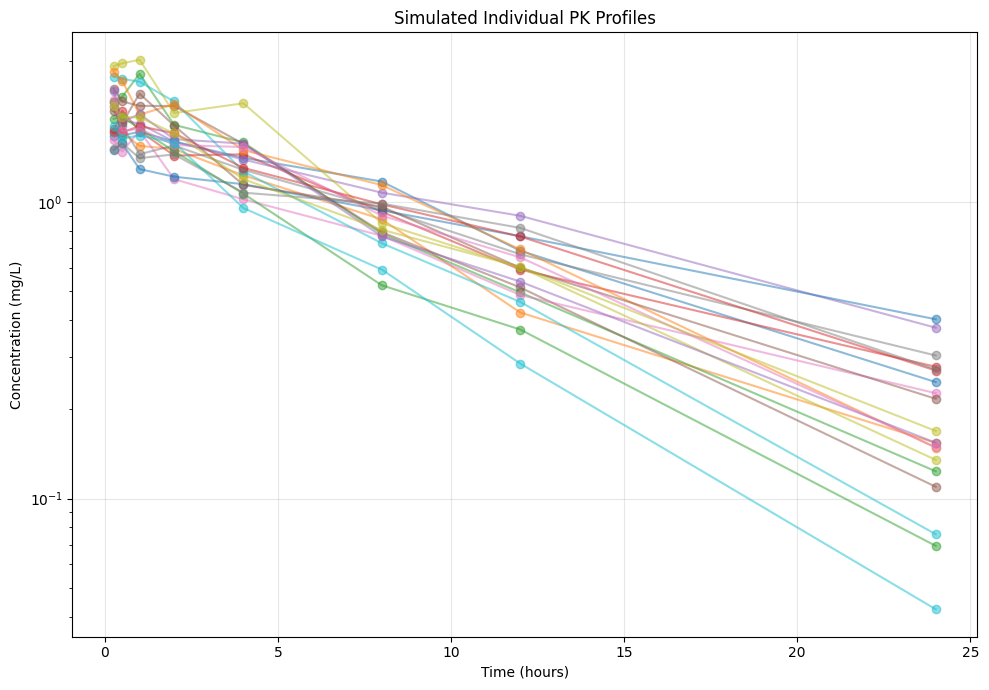

In [12]:
# ============================================================
# 9. VISUALIZE INDIVIDUAL PK PROFILES
# ============================================================

plt.figure(figsize=(10, 7))

for patient_id in population["ID"].sample(20, random_state=42):

    subset = pk_data[
        pk_data["ID"] == patient_id
    ]

    plt.semilogy(
        subset["TIME"],
        subset["CONC_OBS"],
        marker="o",
        alpha=0.5
    )

plt.xlabel("Time (hours)")
plt.ylabel("Concentration (mg/L)")
plt.title("Simulated Individual PK Profiles")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "figures",
        "02_individual_pk_profiles.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

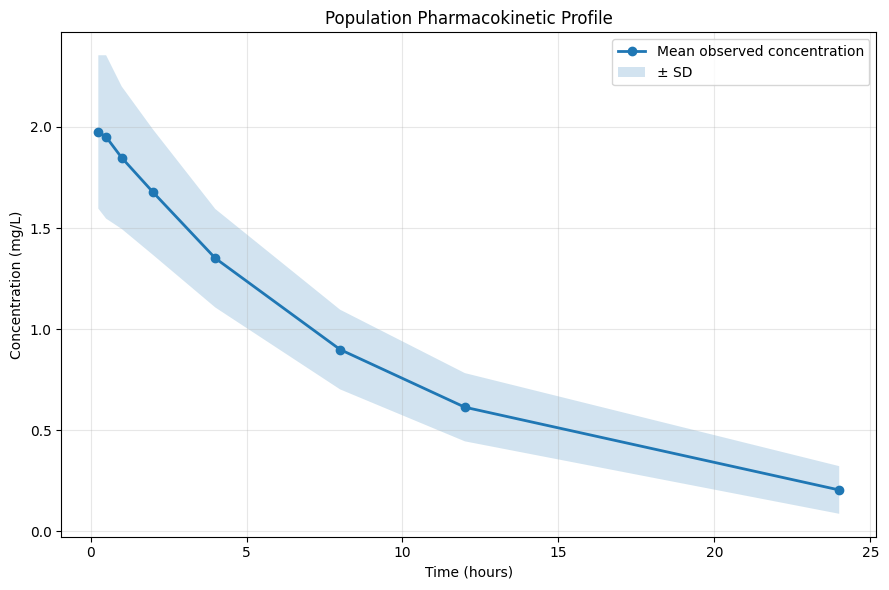

In [13]:
# ============================================================
# 10. POPULATION PK PROFILE
# ============================================================

summary = (
    pk_data
    .groupby("TIME")["CONC_OBS"]
    .agg(["mean", "std", "median"])
    .reset_index()
)

plt.figure(figsize=(9, 6))

plt.plot(
    summary["TIME"],
    summary["mean"],
    marker="o",
    linewidth=2,
    label="Mean observed concentration"
)

plt.fill_between(
    summary["TIME"],
    summary["mean"] - summary["std"],
    summary["mean"] + summary["std"],
    alpha=0.2,
    label="± SD"
)

plt.xlabel("Time (hours)")
plt.ylabel("Concentration (mg/L)")
plt.title("Population Pharmacokinetic Profile")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "figures",
        "03_population_pk_profile.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
# ============================================================
# 11. ESTIMATE TYPICAL POPULATION PARAMETERS
# ============================================================
#
# We estimate CL and V from the population observations.
#
# Objective:
#
# minimize the difference between observed and predicted
# log concentrations.
#
# ============================================================

population_mean_data = (
    pk_data
    .groupby("TIME")["CONC_OBS"]
    .mean()
    .reset_index()
)

fit_time = population_mean_data["TIME"].values
fit_conc = population_mean_data["CONC_OBS"].values


def residual_function(params):

    CL_est, V_est = params

    prediction = pk_concentration_iv_bolus(
        fit_time,
        DOSE,
        CL_est,
        V_est
    )

    residuals = (
        np.log(prediction) -
        np.log(fit_conc)
    )

    return residuals


initial_guess = [
    4.0,
    40.0
]

result = least_squares(
    residual_function,
    initial_guess,
    bounds=(
        [0.01, 1],
        [100, 1000]
    )
)

CL_EST = result.x[0]
V_EST = result.x[1]

print("Estimated population parameters")
print("--------------------------------")
print(f"Estimated CL = {CL_EST:.3f} L/h")
print(f"Estimated V  = {V_EST:.3f} L")
print(
    f"Estimated half-life = "
    f"{np.log(2) * V_EST / CL_EST:.3f} h"
)

Estimated population parameters
--------------------------------
Estimated CL = 4.790 L/h
Estimated V  = 49.759 L
Estimated half-life = 7.200 h


In [15]:
# ============================================================
# 12. MODEL PREDICTIONS
# ============================================================

population_prediction = pk_concentration_iv_bolus(
    fit_time,
    DOSE,
    CL_EST,
    V_EST
)

rmse = np.sqrt(
    mean_squared_error(
        fit_conc,
        population_prediction
    )
)

r2 = r2_score(
    fit_conc,
    population_prediction
)

print("Model performance")
print("------------------")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2:.4f}")

Model performance
------------------
RMSE = 0.0224
R²   = 0.9987


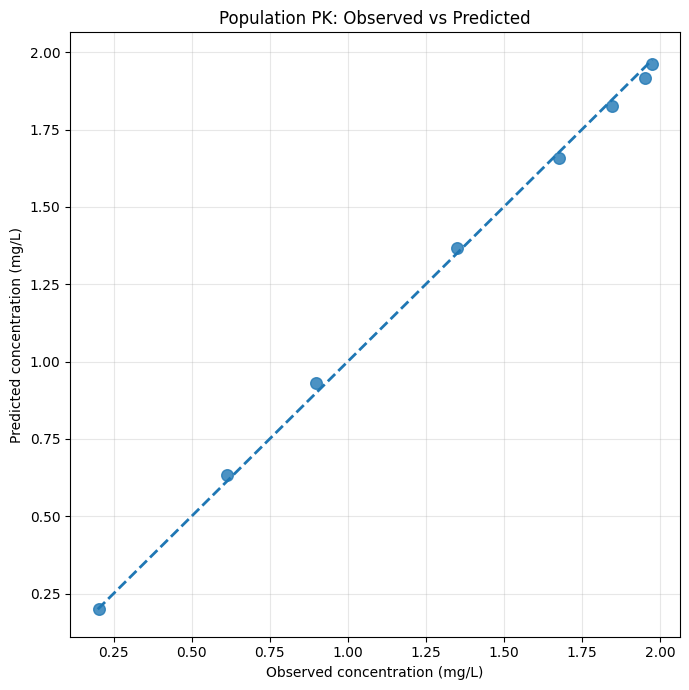

In [16]:
# ============================================================
# 13. OBSERVED VS PREDICTED CONCENTRATIONS
# ============================================================

plt.figure(figsize=(7, 7))

plt.scatter(
    fit_conc,
    population_prediction,
    s=70,
    alpha=0.8
)

minimum = min(
    fit_conc.min(),
    population_prediction.min()
)

maximum = max(
    fit_conc.max(),
    population_prediction.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Observed concentration (mg/L)")
plt.ylabel("Predicted concentration (mg/L)")
plt.title("Population PK: Observed vs Predicted")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "figures",
        "04_observed_vs_predicted.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
# ============================================================
# 14. PHARMACOKINETIC EXPOSURE
# ============================================================
#
# Calculate:
#
# AUC = Dose / Clearance
#
# for an IV bolus dose.
#
# ============================================================

population["AUC_0_inf"] = (
    DOSE /
    population["CL"]
)

population["Cmax"] = (
    DOSE /
    population["V"]
)

population["t_half"] = (
    np.log(2) *
    population["V"] /
    population["CL"]
)

population[
    [
        "ID",
        "CL",
        "V",
        "AUC_0_inf",
        "Cmax",
        "t_half"
    ]
].head()

,ID,CL,V,AUC_0_inf,Cmax,t_half
0,1,5.661090,37.673196,17.664443,2.654407,4.612728
1,2,4.830123,45.965630,20.703409,2.175539,6.596302
2,3,5.878843,46.687670,17.010149,2.141893,5.504727
3,4,7.316963,42.587788,13.666872,2.348091,4.034407
4,5,4.715710,48.412879,21.205713,2.065566,7.116054


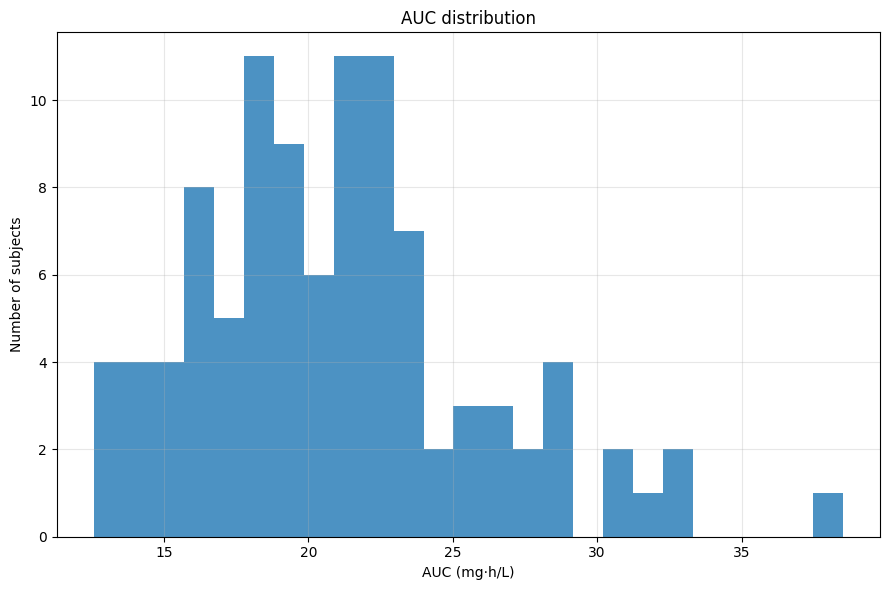

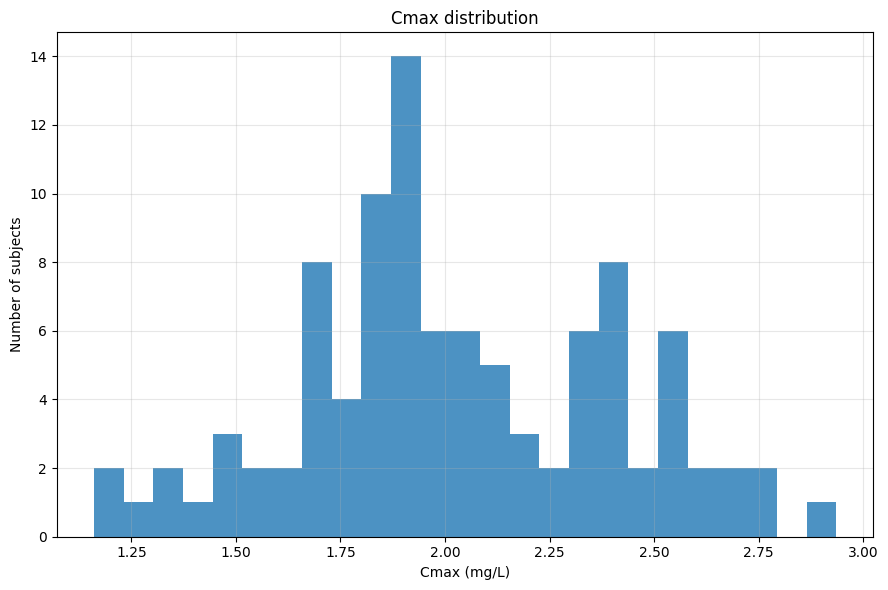

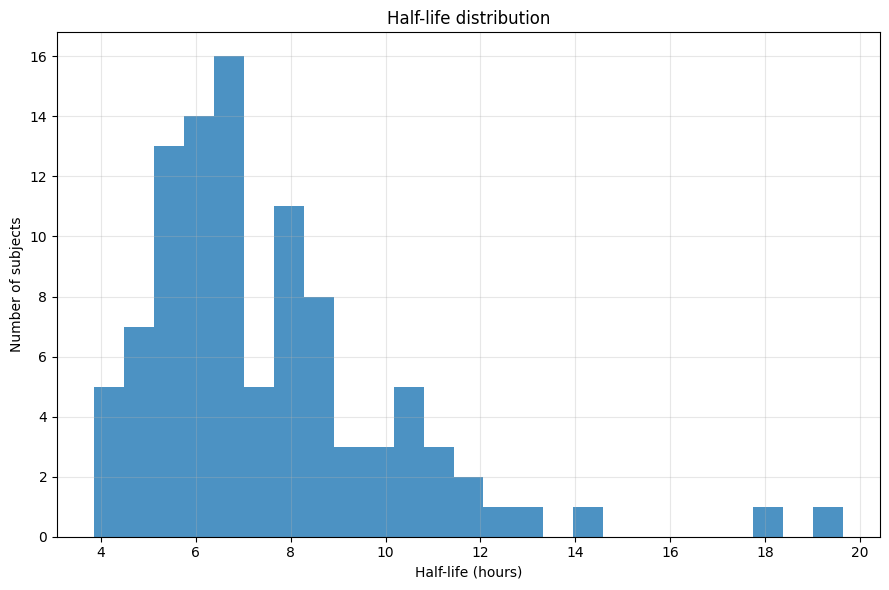

In [18]:
# ============================================================
# 15. EXPOSURE DISTRIBUTION
# ============================================================

figures = [
    ("AUC_0_inf", "AUC distribution", "AUC (mg·h/L)"),
    ("Cmax", "Cmax distribution", "Cmax (mg/L)"),
    ("t_half", "Half-life distribution", "Half-life (hours)")
]

for variable, title, xlabel in figures:

    plt.figure(figsize=(9, 6))

    plt.hist(
        population[variable],
        bins=25,
        alpha=0.8
    )

    plt.xlabel(xlabel)
    plt.ylabel("Number of subjects")
    plt.title(title)

    plt.grid(alpha=0.3)

    plt.tight_layout()

    filename = variable + "_distribution.png"

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            "figures",
            filename
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [19]:
# ============================================================
# 16. PHARMACODYNAMIC MODEL
# ============================================================
#
# Emax model:
#
# E = E0 + Emax*C/(EC50+C)
#
# This represents a saturable exposure-response relationship.
#
# ============================================================

E0 = 10.0
EMAX = 80.0
EC50 = 5.0

population["Effect"] = (
    E0 +
    EMAX *
    population["AUC_0_inf"] /
    (
        EC50 +
        population["AUC_0_inf"]
    )
)

population[
    [
        "ID",
        "AUC_0_inf",
        "Effect"
    ]
].head()

,ID,AUC_0_inf,Effect
0,1,17.664443,72.351210
1,2,20.703409,74.437862
2,3,17.010149,71.826565
3,4,13.666872,68.571664
4,5,21.205713,74.736153


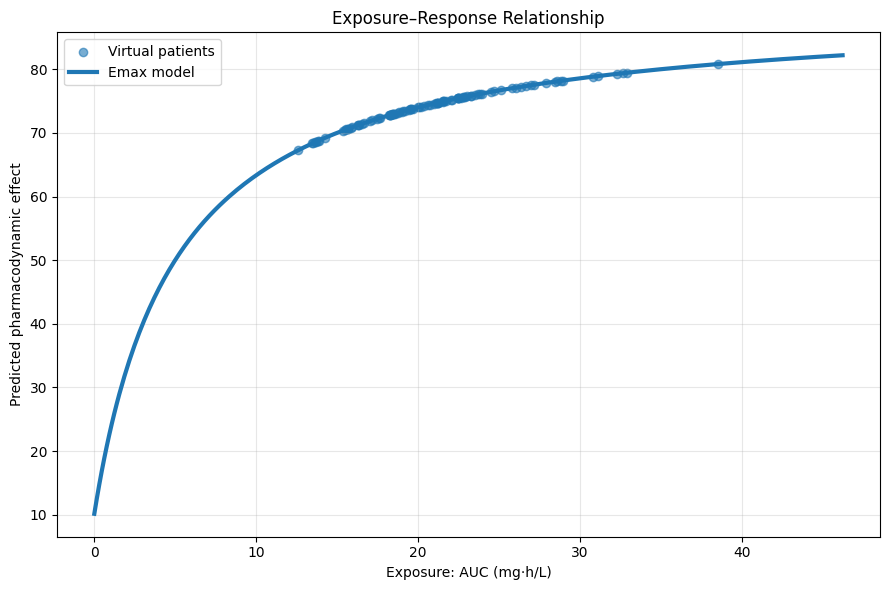

In [20]:
# ============================================================
# 17. EXPOSURE-RESPONSE RELATIONSHIP
# ============================================================

exposure_grid = np.linspace(
    0.01,
    population["AUC_0_inf"].max() * 1.2,
    300
)

effect_curve = (
    E0 +
    EMAX *
    exposure_grid /
    (
        EC50 +
        exposure_grid
    )
)

plt.figure(figsize=(9, 6))

plt.scatter(
    population["AUC_0_inf"],
    population["Effect"],
    alpha=0.6,
    label="Virtual patients"
)

plt.plot(
    exposure_grid,
    effect_curve,
    linewidth=3,
    label="Emax model"
)

plt.xlabel("Exposure: AUC (mg·h/L)")
plt.ylabel("Predicted pharmacodynamic effect")
plt.title("Exposure–Response Relationship")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "figures",
        "05_exposure_response.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
# ============================================================
# 18. DOSE-EXPOSURE SIMULATION
# ============================================================
#
# Evaluate several doses.
#
# ============================================================

dose_levels = [
    25,
    50,
    100,
    200,
    400
]

dose_results = []

for dose in dose_levels:

    auc = dose / population["CL"]

    effect = (
        E0 +
        EMAX *
        auc /
        (
            EC50 +
            auc
        )
    )

    dose_results.append({
        "Dose": dose,
        "Mean_AUC": auc.mean(),
        "Median_AUC": np.median(auc),
        "Mean_Effect": effect.mean(),
        "Median_Effect": np.median(effect)
    })

dose_results = pd.DataFrame(dose_results)

dose_results

,Dose,Mean_AUC,Median_AUC,Mean_Effect,Median_Effect
0,25,5.26581,5.161261,50.509525,50.634727
1,50,10.53162,10.322523,63.638948,63.894543
2,100,21.06324,20.645045,74.136414,74.402364
3,200,42.12648,41.290090,81.160877,81.358787
4,400,84.25296,82.580180,85.310595,85.432724


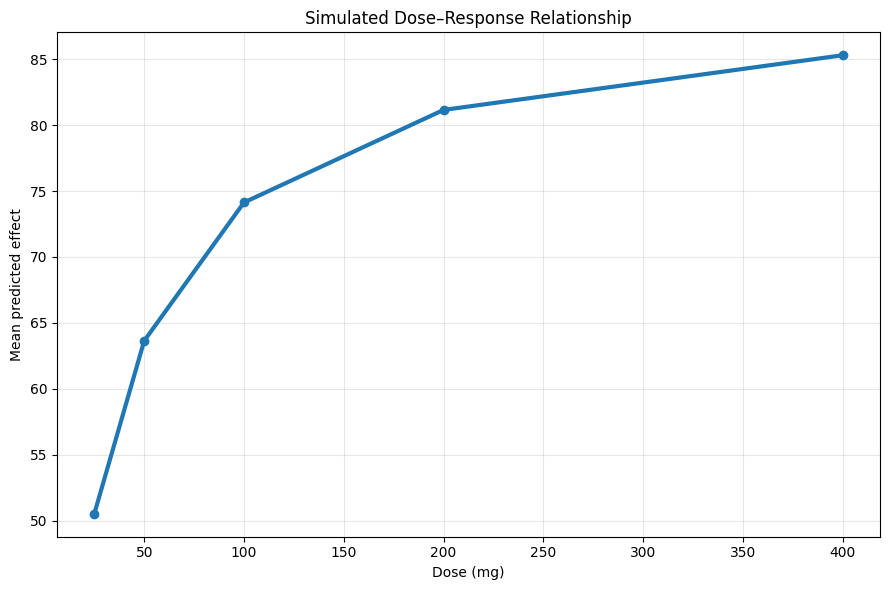

In [22]:
# ============================================================
# 19. DOSE-RESPONSE SUMMARY
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    dose_results["Dose"],
    dose_results["Mean_Effect"],
    marker="o",
    linewidth=3
)

plt.xlabel("Dose (mg)")
plt.ylabel("Mean predicted effect")
plt.title("Simulated Dose–Response Relationship")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "figures",
        "06_dose_response.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
# ============================================================
# 20. MONTE CARLO SIMULATION
# ============================================================
#
# Simulate 10,000 virtual subjects to characterize
# population exposure.
#
# ============================================================

N_MONTE_CARLO = 10_000

mc_eta_cl = np.random.normal(
    0,
    OMEGA_CL,
    N_MONTE_CARLO
)

mc_CL = (
    CL_POP *
    np.exp(mc_eta_cl)
)

mc_auc = DOSE / mc_CL

mc_effect = (
    E0 +
    EMAX *
    mc_auc /
    (
        EC50 +
        mc_auc
    )
)

mc_results = pd.DataFrame({
    "CL": mc_CL,
    "AUC": mc_auc,
    "Effect": mc_effect
})

print("Monte Carlo population size:", len(mc_results))

Monte Carlo population size: 10000


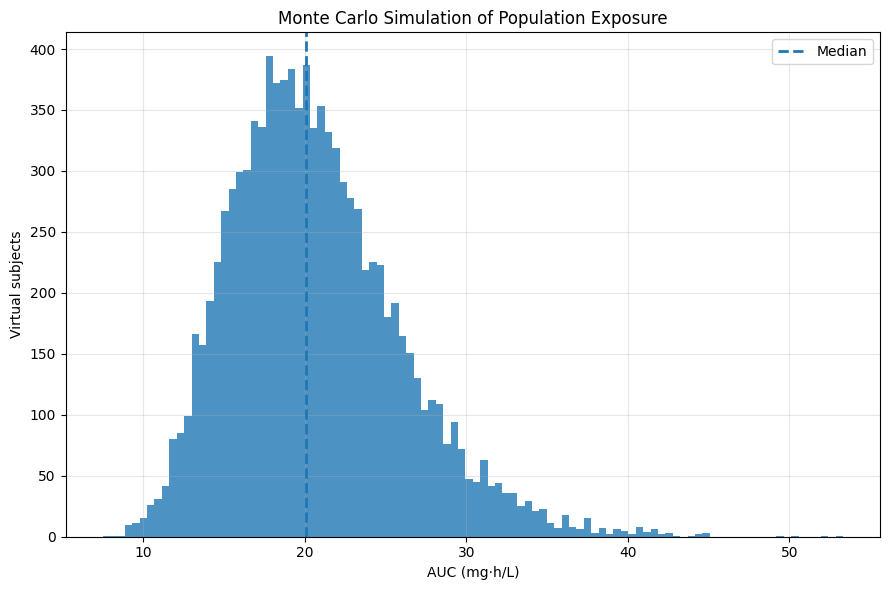

In [24]:
# ============================================================
# 21. MONTE CARLO EXPOSURE DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 6))

plt.hist(
    mc_results["AUC"],
    bins=100,
    alpha=0.8
)

plt.axvline(
    mc_results["AUC"].median(),
    linestyle="--",
    linewidth=2,
    label="Median"
)

plt.xlabel("AUC (mg·h/L)")
plt.ylabel("Virtual subjects")
plt.title("Monte Carlo Simulation of Population Exposure")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "figures",
        "07_monte_carlo_auc.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
# ============================================================
# 22. QUANTIFY EXPOSURE VARIABILITY
# ============================================================

percentiles = [
    1,
    5,
    25,
    50,
    75,
    95,
    99
]

auc_percentiles = np.percentile(
    mc_results["AUC"],
    percentiles
)

percentile_table = pd.DataFrame({
    "Percentile": percentiles,
    "AUC": auc_percentiles
})

percentile_table

,Percentile,AUC
0,1,11.199825
1,5,13.294547
2,25,16.921130
3,50,20.051461
4,75,23.697397
5,95,30.307288
6,99,36.106402


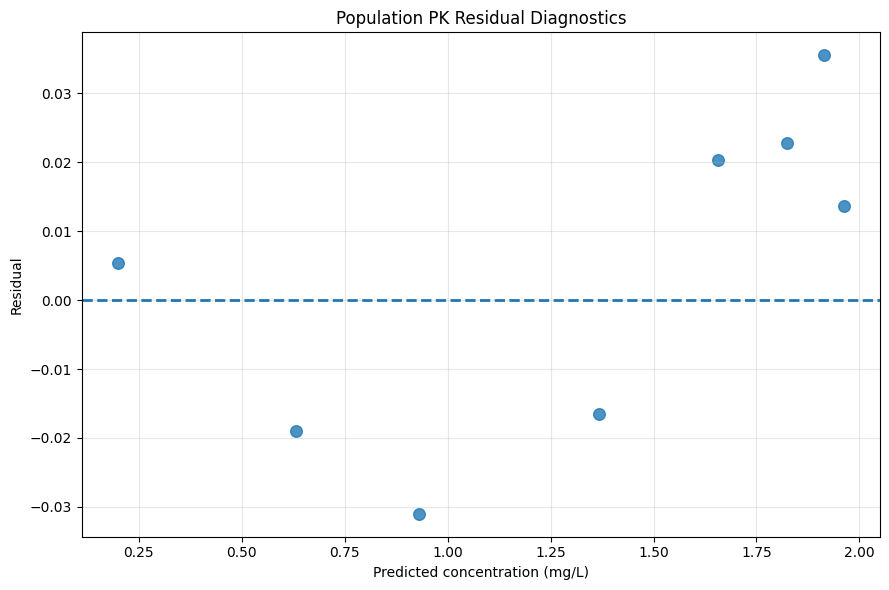

In [26]:
# ============================================================
# 23. MODEL DIAGNOSTICS
# ============================================================

residuals = (
    fit_conc -
    population_prediction
)

plt.figure(figsize=(9, 6))

plt.scatter(
    population_prediction,
    residuals,
    s=70,
    alpha=0.8
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted concentration (mg/L)")
plt.ylabel("Residual")
plt.title("Population PK Residual Diagnostics")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "figures",
        "08_pk_residuals.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
# ============================================================
# 24. MODEL SUMMARY
# ============================================================

model_summary = {
    "model": "One-compartment IV bolus PK + Emax PD",
    "dose_mg": DOSE,
    "true_population_CL_L_per_h": CL_POP,
    "true_population_V_L": V_POP,
    "estimated_population_CL_L_per_h": float(CL_EST),
    "estimated_population_V_L": float(V_EST),
    "estimated_half_life_h": float(
        np.log(2) * V_EST / CL_EST
    ),
    "number_virtual_patients": N_PATIENTS,
    "monte_carlo_population": N_MONTE_CARLO,
    "rmse": float(rmse),
    "r2": float(r2)
}

pd.DataFrame(
    [model_summary]
).to_csv(
    os.path.join(
        OUTPUT_DIR,
        "model_summary.csv"
    ),
    index=False
)

print(json.dumps(
    model_summary,
    indent=4
))

{
    "model": "One-compartment IV bolus PK + Emax PD",
    "dose_mg": 100.0,
    "true_population_CL_L_per_h": 5.0,
    "true_population_V_L": 50.0,
    "estimated_population_CL_L_per_h": 4.790418644975632,
    "estimated_population_V_L": 49.75945943453811,
    "estimated_half_life_h": 7.199919583106188,
    "number_virtual_patients": 100,
    "monte_carlo_population": 10000,
    "rmse": 0.022372151434771732,
    "r2": 0.9987306678413035
}


In [28]:
# ============================================================
# 25. CREATE A REPRODUCIBLE RESULTS TABLE
# ============================================================

final_population = population[
    [
        "ID",
        "CL",
        "V",
        "half_life",
        "AUC_0_inf",
        "Cmax",
        "t_half",
        "Effect"
    ]
].copy()

final_population.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "data",
        "population_pkpd_results.csv"
    ),
    index=False
)

dose_results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "data",
        "dose_response_results.csv"
    ),
    index=False
)

percentile_table.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "data",
        "monte_carlo_exposure_percentiles.csv"
    ),
    index=False
)

print("Results exported successfully.")

Results exported successfully.


In [29]:
# ============================================================
# 26. CREATE GITHUB README
# ============================================================

readme = r"""
# Population PK/PD Modeling and Exposure–Response Simulation

## Overview

This project demonstrates a reproducible pharmacometric-style modeling
workflow using synthetic data.

The project was developed as a quantitative modeling portfolio project
to demonstrate concepts in pharmacokinetics, pharmacodynamics,
population variability, simulation, parameter estimation, and
exposure–response analysis.

## Objectives

- Develop a one-compartment pharmacokinetic model
- Simulate a virtual patient population
- Incorporate inter-individual variability
- Simulate residual unexplained variability
- Estimate population PK parameters
- Evaluate model predictions
- Calculate exposure metrics
- Implement an Emax pharmacodynamic model
- Perform exposure–response analysis
- Perform Monte Carlo population simulation
- Evaluate dose-exposure-response relationships

## Methods

### Pharmacokinetic model

A one-compartment IV bolus model was used:

dA/dt = -kA

where:

k = CL/V

and:

C(t) = A(t)/V

### Population variability

Individual clearance and volume were simulated using log-normal
inter-individual variability:

CL_i = CL_pop × exp(η_CL)

V_i = V_pop × exp(η_V)

### Pharmacodynamic model

An Emax exposure-response model was implemented:

E = E0 + Emax × AUC / (EC50 + AUC)

## Software

- Python
- NumPy
- Pandas
- SciPy
- Matplotlib
- Scikit-learn
- Seaborn

## Outputs

The project generates:

- Individual PK profiles
- Population PK profile
- Observed vs predicted diagnostics
- Residual diagnostics
- AUC distributions
- Cmax distributions
- Half-life distributions
- Exposure-response curves
- Dose-response simulations
- Monte Carlo exposure simulations

## Important Note

All datasets in this project are synthetic and generated for educational
and portfolio purposes. No clinical trial or patient data are used.

## Author

Pawan Kumar Thapaliya
"""

with open(
    os.path.join(
        OUTPUT_DIR,
        "README.md"
    ),
    "w"
) as f:
    f.write(readme)

print("README.md created.")

README.md created.


In [30]:
# ============================================================
# 27. LIST ALL GENERATED FILES
# ============================================================

for root, dirs, files in os.walk(OUTPUT_DIR):

    level = root.replace(
        OUTPUT_DIR,
        ""
    ).count(os.sep)

    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    subindent = "    " * (level + 1)

    for file in files:
        print(f"{subindent}{file}")

pkpd_project/
    PROJECT_DESCRIPTION.txt
    README.md
    model_summary.csv
    figures/
        01_one_compartment_pk.png
        05_exposure_response.png
        04_observed_vs_predicted.png
        AUC_0_inf_distribution.png
        Cmax_distribution.png
        06_dose_response.png
        07_monte_carlo_auc.png
        08_pk_residuals.png
        03_population_pk_profile.png
        t_half_distribution.png
        02_individual_pk_profiles.png
    data/
        synthetic_population_pk.csv
        virtual_population_parameters.csv
        dose_response_results.csv
        monte_carlo_exposure_percentiles.csv
        population_pkpd_results.csv
